In [125]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

In [126]:
Rx_riferimento = 1.9515 * 1000
Rx_riferimento_err = 0.0009139826042 * 1000

data = {

    "R_A" : np.array([
            27.14,
            46.92,
            99.93,
            219.67,
            329.51,
            389.52,
            469.39,
            558.31,
            680.05,
            747.08,
            1001.9,
            1205.9,
            1496.8,
            1797.3,
            2202.7,
    ]),

    "R_B" : np.array([
            27.17,
            46.97,
            99.8,
            220.21,
            329.66,
            389.51,
            470.38,
            560.44,
            680.25,
            746.67,
            1004.3,
            1212.4,
            1497.8,
            1799.4,
            2200.9,
    ]),

    "k" : np.array([
        1.666666667,
        1.352569883,
        1.142857143,
        1.072961373,
        1.088139282,
        1.102941176,
        1.121914734,
        1.148545176,
        1.19379228,
        1.218026797,
        1.307189542,
        1.378676471,
        1.49551346,
        1.610305958,
        1.769911504,
    ]),

    "rho" : np.array([
        0.998895841,
        0.9989354907,
        1.001302605,
        0.9975477953,
        0.9995449857,
        1.000025673,
        0.9978953187,
        0.9961994147,
        0.9997059904,
        1.000549105,
        0.9976102758,
        0.9946387331,
        0.9993323541,
        0.9988329443,
        1.000817847
    ]),

    "sigma_rho" : np.array([
        0.002537434164,
        0.001611567849,
        0.001047540664,
        0.0008667016728,
        0.0008398230726,
        0.0008335610131,
        0.0008265026096,
        0.0008216698895,
        0.0008218834713,
        0.00082161804,
        0.0008643601194,
        0.0007822325737,
        0.000718533774,
        0.000676406693,
        0.0006444807734,
    ])
}

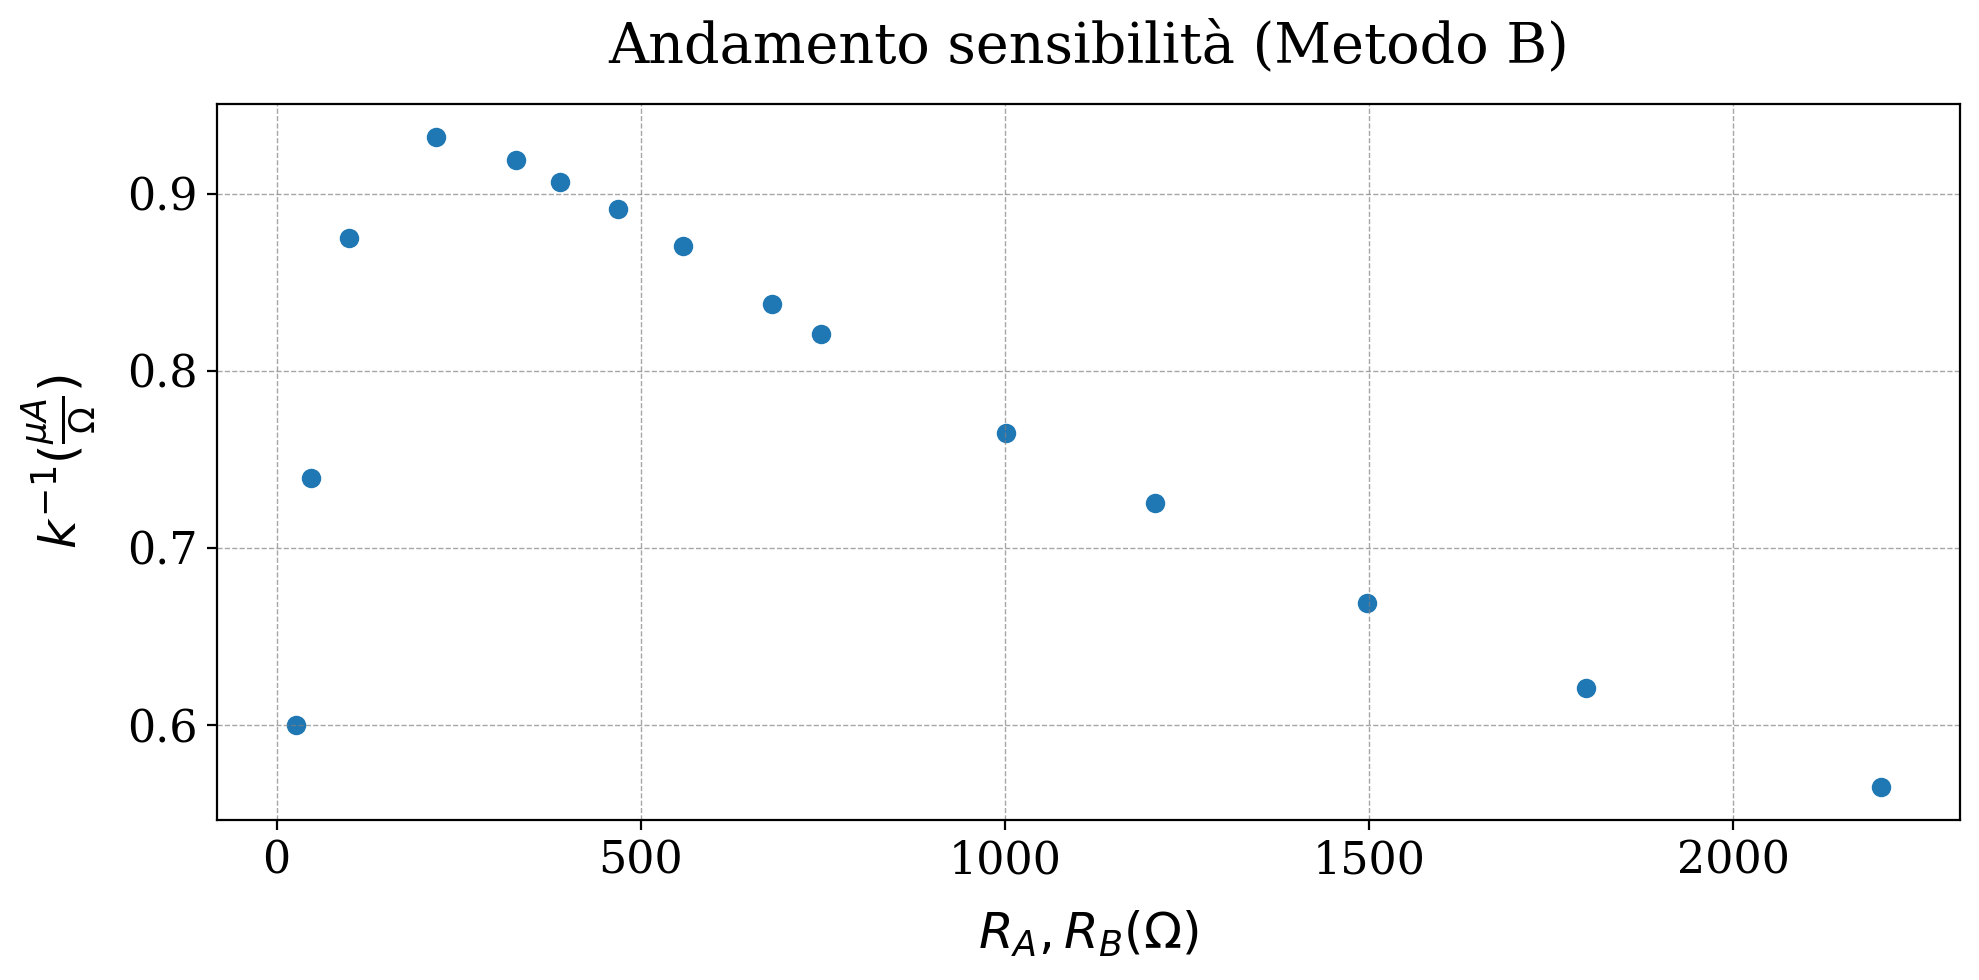

In [127]:
k = 1/data["k"]
dati = data["R_A"]
fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
gf.parametri_grafico(ax,"Andamento sensibilità (Metodo B)",xlabel=r"$R_A,R_B (Ω)$",ylabel=r"$k^{-1} (\frac{μA}{Ω})$")
ax.scatter(dati, k)
gf.salva_grafico(fig,f"Slide 1.pdf")

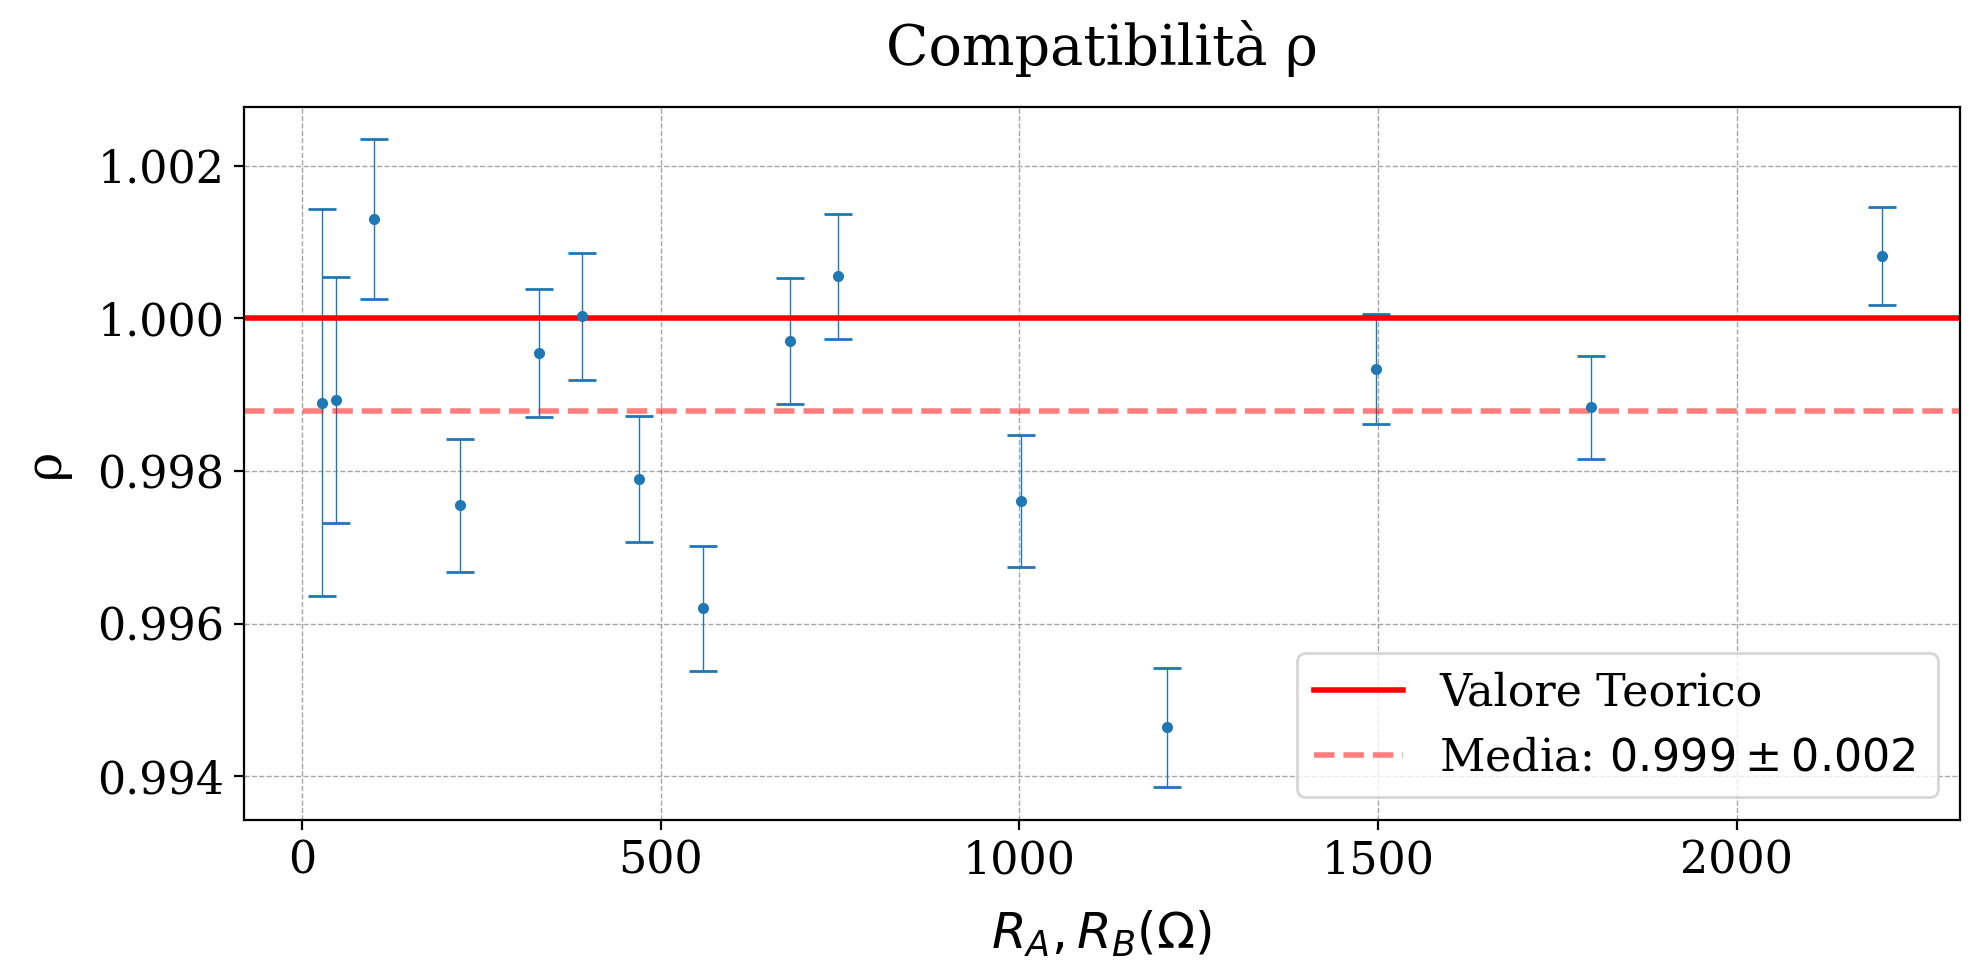

In [128]:
from scipy.optimize import curve_fit

titolo1 = "Istogramma ρ"
titolo2 = "Compatibilità ρ"
dati = data["rho"]
errori = data["sigma_rho"]

"""
fig1,ax1 = plt.subplots(1, 1,  figsize=(10, 5), sharex=True, sharey=True)

h = 0.002
bins = np.arange(dati.min(), dati.max() + h, h)

counts, edges = np.histogram(dati, bins=bins)
centers = (edges[:-1] + edges[1:]) / 2

def gauss(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

p0 = [counts.max(), np.mean(dati), np.std(dati)]
popt, pcov = curve_fit(gauss, centers, counts, p0=p0)
A_fit, mu_fit, sigma_fit = popt

#f.residui(gauss, centers, counts, popt)

ax1.hist(dati, bins=bins)
x = np.linspace(0.994, 1.004, 500)
ax1.plot(x, gauss(x, A_fit, mu_fit, sigma_fit))
gf.parametri_grafico(ax1,titolo1,xlabel="ρ",ylabel="Frequenza")

legenda = (
    f"A = {A_fit:.1f}\n"
    f"mu = {mu_fit:.5f}\n"
    f"sigma = {sigma_fit:.5f}"
)
gf.descrizione_legenda(ax1,legenda)
plt.legend(loc="upper right", frameon=True)
gf.salva_grafico(fig1,f"{titolo1}.pdf")
"""

fig2,ax2 = plt.subplots(1, 1,  figsize=(10, 5), sharex=True, sharey=True)
gf.parametri_grafico(ax2,titolo2,xlabel=r"$R_A, R_B (Ω)$",ylabel="ρ")
ax2.errorbar(data["R_A"],dati,errori,fmt=".", **gf.default_error_params())
ax2.axhline(y=1, color="red", label="Valore Teorico")
errore = 0.001721694905
ax2.axhline(y=np.mean(dati), color="red", linestyle="dashed", alpha=0.5, label=f"Media: {gf.formatta_errore(np.mean(dati),errore)}")

plt.legend(loc="lower right", frameon=True)
gf.salva_grafico(fig2,"Slide 2.pdf")

In [129]:
risultati = {
    "Metodo A": {
        "valori": [1952.495029, 1956.878672, 1952.013541, 1952.013541],
        "casuale": [0.62252, 11.37116867, 1.021434682, 1.239244086],
        "totale": [0.8945135789, 11.38929762, 1.206628444, 1.395832833]
    },
    "Metodo B": {
        "valori": [1953.357057, 1953.76924, 1953.456623, 1953.456623],
        "casuale": [1.06228, 1.85249547, 1.490982329, 1.249007674],
        "totale": [1.24139526, 1.960704684, 1.623469032, 1.404508299]
    }
}

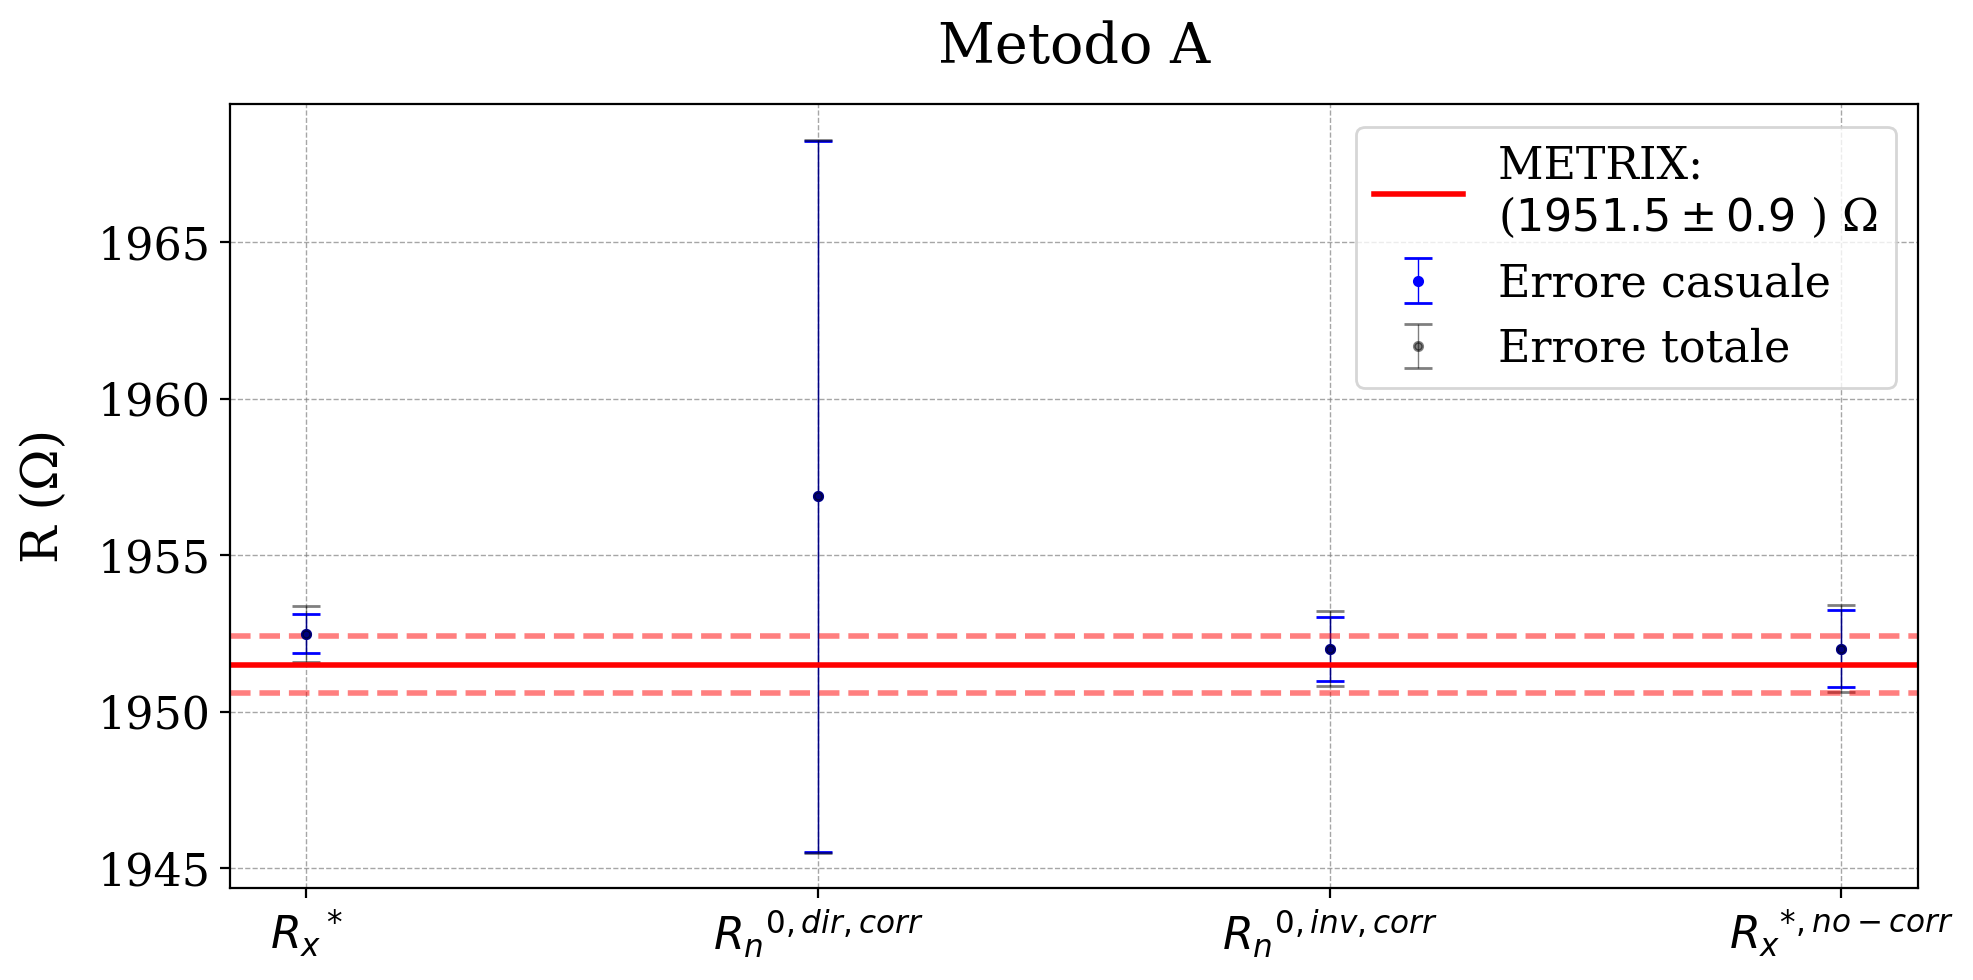

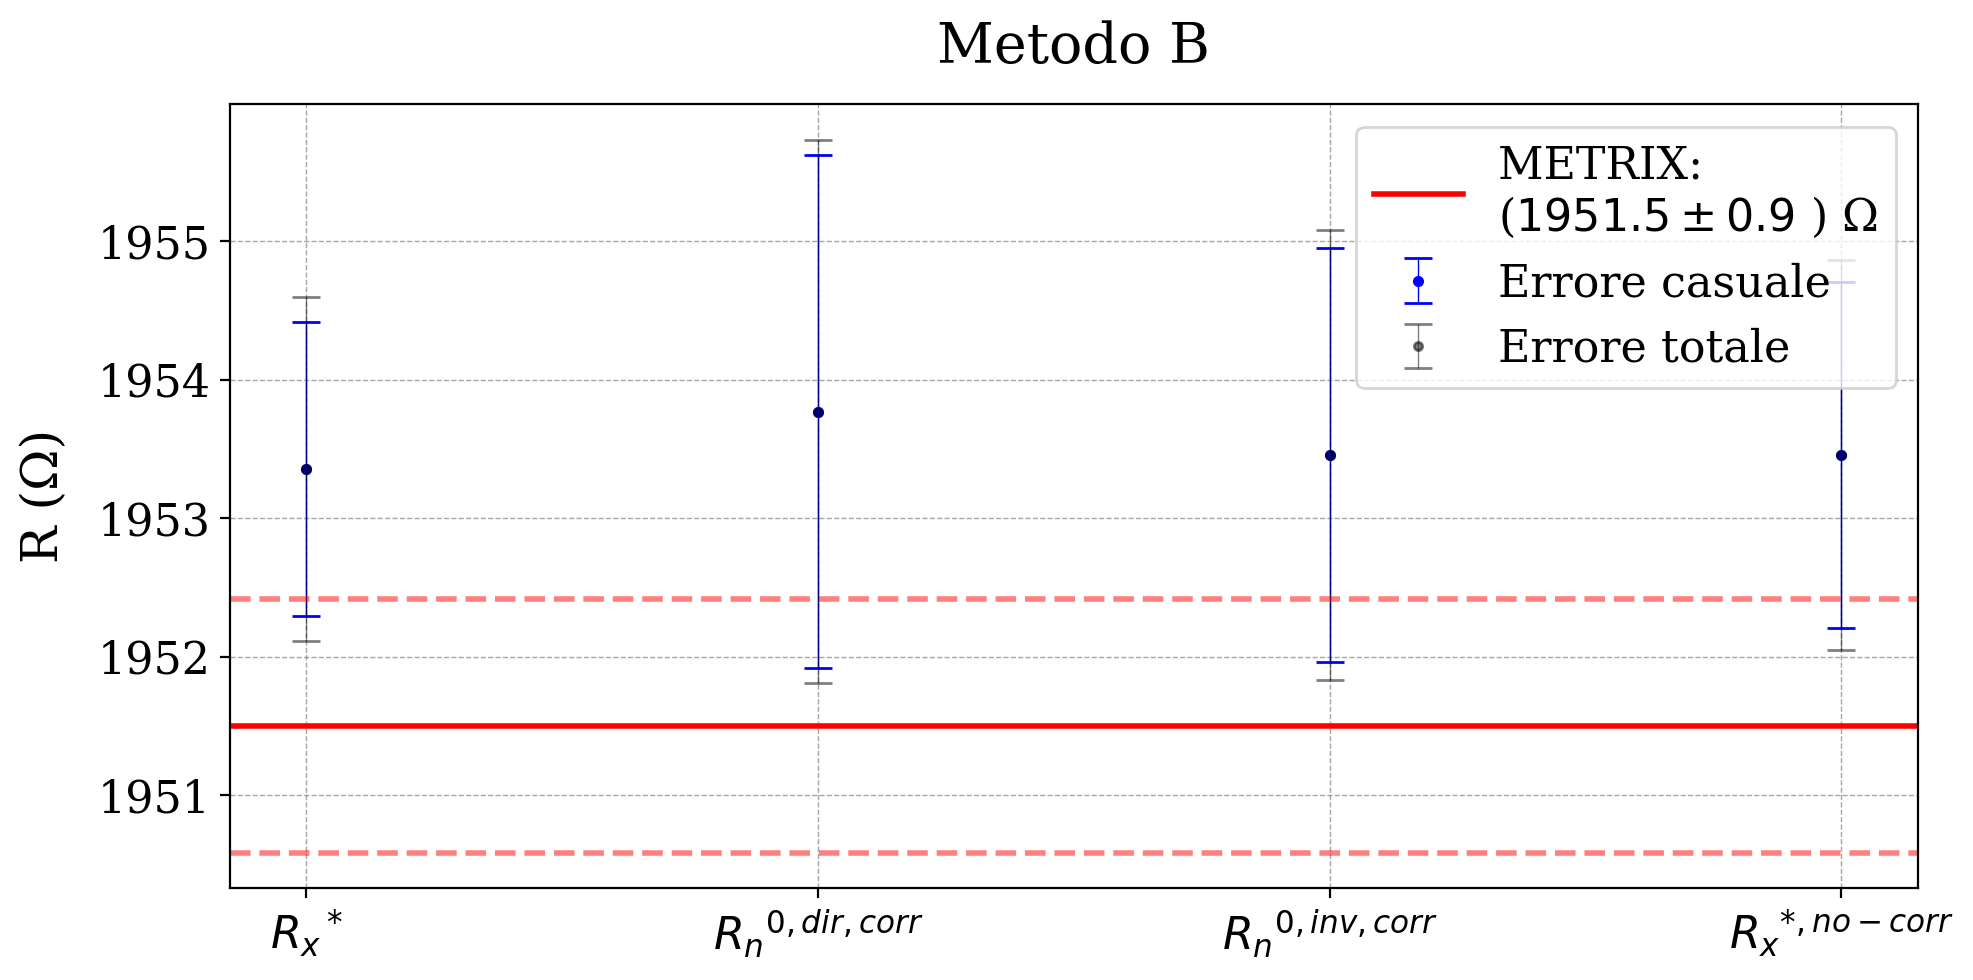

In [130]:
labels = [r"${R_x}^*$", r"${R_n}^{0,dir,corr}$", r"${R_n}^{0,inv,corr}$", r"${R_x}^{*, no-corr}$"]

for i, (metodo,dati)  in enumerate(risultati.items()):

    fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
    gf.parametri_grafico(ax,metodo,xlabel="",ylabel="R (Ω)")

    ax.set_xticks([1, 2, 3, 4])
    ax.set_xticklabels(labels)
    ax.errorbar([1,2,3,4], dati["valori"], dati["casuale"], fmt=".", color="blue", label="Errore casuale", **gf.default_error_params())
    ax.errorbar([1,2,3,4], dati["valori"], dati["totale"], fmt=".", label="Errore totale", color="black", **gf.default_error_params(), alpha=0.5)

    ax.axhline(y=Rx_riferimento, color="red", label=f"METRIX: \n({gf.formatta_errore(Rx_riferimento, Rx_riferimento_err)}) Ω")
    ax.axhline(y=Rx_riferimento + Rx_riferimento_err, color="red", linestyle="dashed", alpha=0.5)
    ax.axhline(y=Rx_riferimento - Rx_riferimento_err, color="red", linestyle="dashed", alpha=0.5)
    ax.legend(loc="upper right", frameon=True)
    gf.salva_grafico(fig,f"Slide 3.{i+1}.pdf")

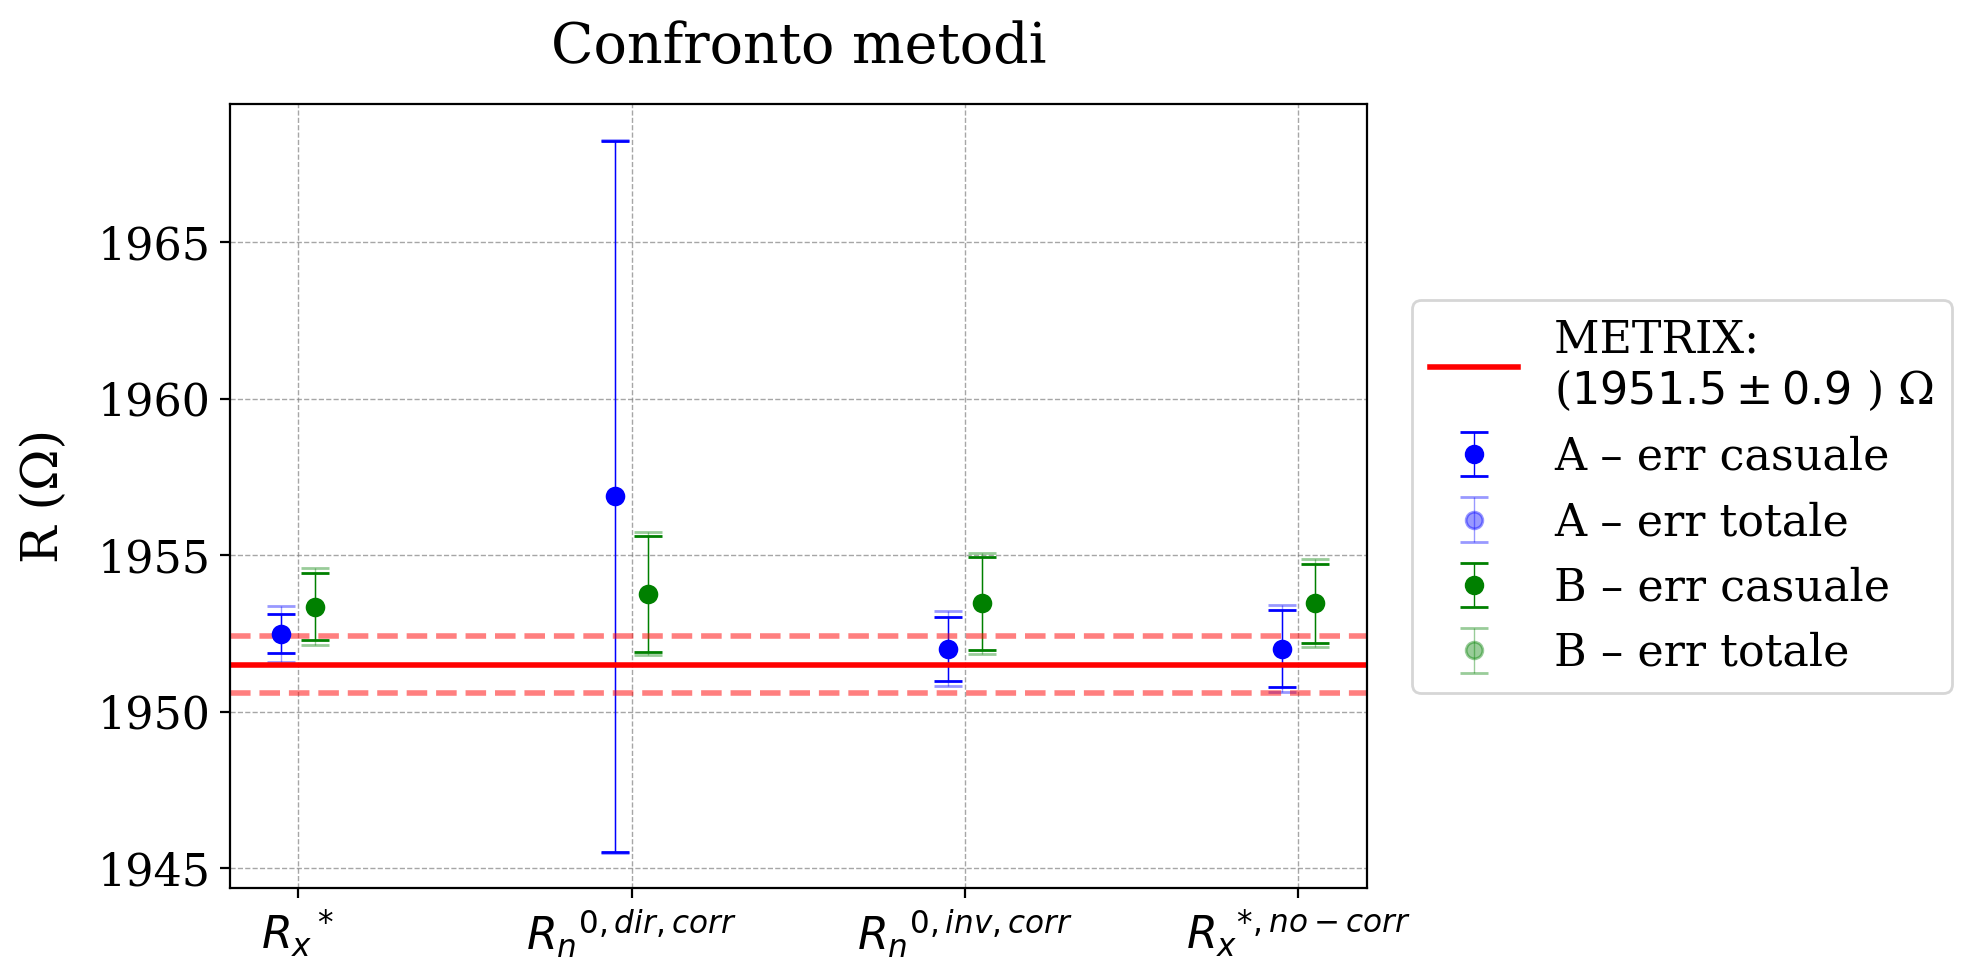

In [131]:
fig, ax = plt.subplots(1,1, figsize=(10,5))
gf.parametri_grafico(ax, "Confronto metodi", xlabel="", ylabel="R (Ω)")

x = np.array([1,2,3,4])

ax.set_xticks(x)
ax.set_xticklabels(labels)

colori = {
    "Metodo A": "blue",
    "Metodo B": "green"
}

offset = {
    "Metodo A": -0.05,
    "Metodo B": 0.05
}

metod = ["A","B"]

for i,(metodo,dati) in enumerate(risultati.items()):

    x_plot = x + offset[metodo]

    ax.errorbar(
        x_plot,
        dati["valori"],
        dati["casuale"],
        fmt="o",
        color=colori[metodo],
        label=f"{metod[i]} – err casuale",
        **gf.default_error_params()
    )

    ax.errorbar(
        x_plot,
        dati["valori"],
        dati["totale"],
        fmt="o",
        color=colori[metodo],
        alpha=0.4,
        label=f"{metod[i]} – err totale",
        **gf.default_error_params()
    )

ax.axhline(y=Rx_riferimento, color="red", label=f"METRIX: \n({gf.formatta_errore(Rx_riferimento, Rx_riferimento_err)}) Ω")
ax.axhline(y=Rx_riferimento + Rx_riferimento_err, color="red", linestyle="dashed", alpha=0.5)
ax.axhline(y=Rx_riferimento - Rx_riferimento_err, color="red", linestyle="dashed", alpha=0.5)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)
gf.salva_grafico(fig, "Slide 3.pdf")